In [1]:
from datasets.coco_lvis import LvisDataset
from datasets.hqseg44k import HQSeg44KTrainDataset, HQSeg44KTestDataset
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
from datasets import instance_info
import json

/home/clc/miniconda3/envs/var/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# datasets = LvisDataset(
#     dataset_path='data/coco_lvis',
#     split='val',
#     img_split='val',
#     stuff_prob=0.0,
# )
datasets = HQSeg44KTestDataset(
    data_root='data/sam-hq',
    img_size=(512, 512)
)


Loading DIS5K/DIS-VD: 100%|██████████| 464/464 [00:00<00:00, 1129516.57it/s]


In [3]:
_ = datasets[0]

In [4]:
def visualize_mask(image, layers, instances_info, alpha=0.5):
    plt.imshow(image // 2)
    # for inst_id, inst_info in instances_info.items():   
    #     if inst_info.parent is None:
    #         masked_data = np.ma.masked_where(layers[:, :, inst_info.mapping[0]] == 0, layers[:, :, inst_info.mapping[0]])
    #         plt.imshow(masked_data, alpha=alpha)
    for l in range(layers.shape[-1]):
        masked_data = np.ma.masked_where(layers[:, :, l] == 0, layers[:, :, l])
        plt.imshow(masked_data, alpha=alpha, cmap='tab20c')
    plt.show()

In [5]:
data_iter = iter(datasets)

(512, 512, 3)
(512, 512, 1)
{0: InstanceInfo(mapping=(0, 1), parent=None, children=[], node_level=0)}


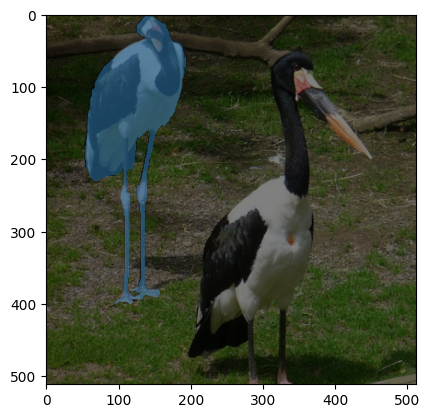

In [6]:
image, layers, instances_info = next(data_iter)

print(image.shape)
print(layers.shape)
print(instances_info)
visualize_mask(image, layers, instances_info, alpha=0.5)


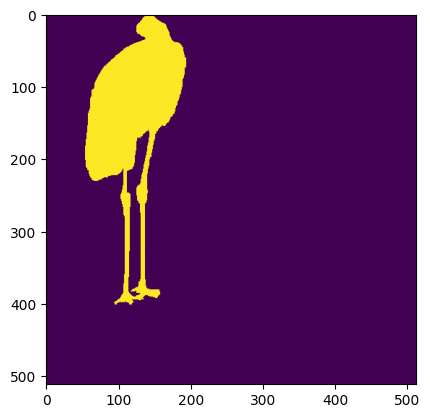

In [8]:
mask = layers[:, :, instances_info[0].mapping[0]]
plt.imshow(mask==instances_info[0].mapping[1])